# Notebook 26 — Contrastive Shape Manifold

**The question:** nb25 trained the same transformer with cross-entropy loss and produced an address-book geometry — 8 equidistant corners, Spearman ρ = −0.31 vs the 6-feature fingerprint. Cross-entropy only asks "route each input to the right corner." It has no incentive to place similar classes nearby.

**The fix:** Supervised Contrastive Loss (SupCon, Khosla et al. 2020). Instead of predicting a label, the model must place same-class instances close together and different-class instances far apart — in every batch, for every pair. This directly encodes similarity geometry rather than classification routing.

**The bet:** A contrastive encoder will produce a manifold where the between-class distances reflect genuine structural similarity. The 6-feature fingerprint and the contrastive transformer should agree on which classes are close — because both are measuring something real about the shape structure, just from different angles.

**If ρ rises above nb25's −0.31 (ideally positive and significant):** the loss function was the problem, not the transformer. The shape manifold is there; cross-entropy just doesn't look for it.

**If ρ stays near zero or negative:** the two representations are measuring genuinely orthogonal aspects of the series. The thunder hypothesis holds at the manifold level too — not just at the boundary level.

---

## Pre-run Predictions

| Test | Prediction | Reasoning |
|---|---|---|
| Spearman ρ vs 6-feature | > 0 (positive, ideally > 0.4) | Contrastive loss forces similarity geometry; should align with 6-feature's similarity structure |
| Closest pair in embedding | eco_cycle ↔ seasonal or trend ↔ integrated_trend | Both pairs are close in 6-feature space; contrastive should recover this |
| Most distant pair | burst ↔ trend or burst ↔ oscillator | Maximum waveform dissimilarity; both representations should agree |
| Distance range (max/min ratio) | > 3x (much wider than nb25's 1.27x) | Contrastive loss explicitly maximises separation — no compression to equidistance |
| Continuous manifold visible | Yes — arc or curved structure in UMAP | Similarity-encoding space should show gradients, not isolated islands |


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = [
    'burst', 'eco_cycle', 'oscillator', 'seasonal',
    'trend', 'integrated_trend', 'irregular_osc', 'declining_osc'
]
N_CLASSES = len(CLASS_NAMES)
SEQ_LEN   = 64

print(f'PyTorch {torch.__version__}  device: {device}')

PyTorch 2.11.0+cu130  device: cuda


In [3]:
# ============================================================
# Shape generators — identical to nb25
# ============================================================

def zscore(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 1e-8 else s - s.mean()

t64 = np.linspace(0, 1, SEQ_LEN)

def gen_burst(rng):
    peak  = rng.uniform(0.15, 0.50)
    width = rng.uniform(0.05, 0.15)
    noise = rng.uniform(0.02, 0.08)
    s = np.exp(-(t64 - peak)**2 / (2 * width**2))
    return zscore(s + rng.normal(0, noise, SEQ_LEN))

def gen_eco_cycle(rng):
    periods = rng.uniform(1.5, 3.5)
    freq    = 2 * np.pi * periods
    ratio   = rng.uniform(0.3, 0.6)
    noise   = rng.uniform(0.08, 0.20)
    s = np.sin(freq * t64) + ratio * np.sin(2 * freq * t64)
    return zscore(s + rng.normal(0, noise, SEQ_LEN))

def gen_oscillator(rng):
    periods = rng.uniform(1.5, 4.5)
    freq    = 2 * np.pi * periods
    noise   = rng.uniform(0.02, 0.10)
    s = np.sin(freq * t64 + rng.uniform(0, np.pi))
    return zscore(s + rng.normal(0, noise, SEQ_LEN))

def gen_seasonal(rng):
    freq  = 2 * np.pi * rng.uniform(3, 6)
    ratio = rng.uniform(0.15, 0.35)
    noise = rng.uniform(0.02, 0.06)
    s = np.sin(freq * t64) + ratio * np.sin(2 * freq * t64)
    return zscore(s + rng.normal(0, noise, SEQ_LEN))

def gen_trend(rng):
    curvature = rng.uniform(0.05, 0.30)
    noise     = rng.uniform(0.01, 0.04)
    s = t64 + curvature * t64**2
    return zscore(s + rng.normal(0, noise, SEQ_LEN))

def gen_integrated_trend(rng):
    drift = rng.uniform(0.015, 0.035)
    noise = rng.uniform(0.001, 0.006)
    s = np.cumsum(np.ones(SEQ_LEN) * drift + rng.normal(0, noise, SEQ_LEN))
    return zscore(s)

def gen_irregular_osc(rng):
    freq = 2 * np.pi * rng.uniform(2, 5)
    s    = np.sin(freq * t64) * (1 + rng.uniform(0.3, 0.8, SEQ_LEN))
    s   += rng.normal(0, rng.uniform(0.2, 0.5), SEQ_LEN)
    s    = s + 0.4 * np.abs(s)
    return zscore(s)

def gen_declining_osc(rng):
    periods   = rng.uniform(2.5, 5.5)
    freq      = 2 * np.pi * periods
    amp_start = rng.uniform(0.9, 1.2)
    amp_end   = rng.uniform(0.35, 0.65)
    shift_end = rng.uniform(-0.8, -0.4)
    amplitude  = np.linspace(amp_start, amp_end, SEQ_LEN)
    mean_shift = np.linspace(0.0, shift_end, SEQ_LEN)
    noise      = rng.uniform(0.03, 0.08)
    s = amplitude * np.sin(freq * t64) + mean_shift
    return zscore(s + rng.normal(0, noise, SEQ_LEN))


GENERATORS = [
    gen_burst, gen_eco_cycle, gen_oscillator, gen_seasonal,
    gen_trend, gen_integrated_trend, gen_irregular_osc, gen_declining_osc
]

print('Generators loaded.')

Generators loaded.


In [4]:
# ============================================================
# Dataset — same split as nb25
# ============================================================

N_PER_CLASS = 500
N_TRAIN     = 400
N_VAL       = 100

X_train_list, y_train_list = [], []
X_val_list,   y_val_list   = [], []

for cls_id, gen_fn in enumerate(GENERATORS):
    cls_series = []
    for i in range(N_PER_CLASS):
        rng_i = np.random.default_rng(SEED + cls_id * 10000 + i)
        cls_series.append(gen_fn(rng_i))
    arr = np.stack(cls_series)
    X_train_list.append(arr[:N_TRAIN])
    y_train_list.extend([cls_id] * N_TRAIN)
    X_val_list.append(arr[N_TRAIN:])
    y_val_list.extend([cls_id] * N_VAL)

X_train = torch.tensor(np.concatenate(X_train_list), dtype=torch.float32)
y_train = torch.tensor(y_train_list, dtype=torch.long)
X_val   = torch.tensor(np.concatenate(X_val_list),   dtype=torch.float32)
y_val   = torch.tensor(y_val_list,   dtype=torch.long)

perm    = torch.randperm(len(X_train))
X_train, y_train = X_train[perm], y_train[perm]

print(f'Train: {len(X_train)}  Val: {len(X_val)}')

Train: 3200  Val: 800


In [5]:
# ============================================================
# Supervised Contrastive Loss (Khosla et al. 2020)
# For each anchor: pull all same-class instances close,
# push all different-class instances far.
# Uses ALL positive pairs in the batch — more signal than triplet.
# ============================================================

class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.tau = temperature

    def forward(self, features, labels):
        # features: [N, D] — must be L2-normalised before passing in
        # labels:   [N]
        N = features.size(0)
        device = features.device

        # Cosine similarity matrix scaled by temperature
        sim = torch.mm(features, features.T) / self.tau  # [N, N]

        # Masks
        mask_self = torch.eye(N, device=device).bool()
        mask_pos  = (labels.unsqueeze(1) == labels.unsqueeze(0)) & ~mask_self  # [N, N]

        # Numerical stability: subtract row max
        sim_max, _ = sim.detach().max(dim=1, keepdim=True)
        sim = sim - sim_max

        exp_sim = torch.exp(sim)
        # Denominator: all pairs except self
        denom = exp_sim.masked_fill(mask_self, 0).sum(dim=1, keepdim=True)  # [N, 1]

        log_prob = sim - torch.log(denom + 1e-8)  # [N, N]

        # Average log-prob over positive pairs for each anchor
        n_pos = mask_pos.float().sum(dim=1).clamp(min=1)
        loss  = -(mask_pos.float() * log_prob).sum(dim=1) / n_pos
        return loss.mean()


# Quick sanity check
_f = torch.randn(16, 32)
_f = nn.functional.normalize(_f, dim=1)
_l = torch.tensor([0,0,1,1,2,2,3,3,4,4,5,5,6,6,7,7])
_loss = SupConLoss()(_f, _l)
print(f'SupConLoss check: {_loss.item():.4f}  (should be finite positive)')

SupConLoss check: 5.2317  (should be finite positive)


In [6]:
# ============================================================
# Model — same transformer encoder as nb25
# Added: a small projection head for the contrastive loss.
# The projection head is used only during training.
# Downstream analysis uses the raw encoder output (64-dim).
# ============================================================

PROJ_DIM = 32  # projection space for contrastive loss


class ShapeEncoder(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, d_model=64, n_heads=4,
                 n_layers=2, d_ff=256, proj_dim=PROJ_DIM, dropout=0.1):
        super().__init__()
        self.d_model    = d_model
        self.input_proj = nn.Linear(1, d_model)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_embed  = nn.Embedding(seq_len + 1, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_ff, dropout=dropout,
            batch_first=True, norm_first=True
        )
        self.encoder  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm     = nn.LayerNorm(d_model)

        # Projection head: used for contrastive loss only
        self.projector = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, proj_dim)
        )

    def _backbone(self, x):
        b = x.size(0)
        x   = self.input_proj(x.unsqueeze(-1))
        cls = self.cls_token.expand(b, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        pos = torch.arange(x.size(1), device=x.device)
        x   = x + self.pos_embed(pos)
        x   = self.encoder(x)
        return self.norm(x[:, 0])  # [b, d_model]

    def forward(self, x):
        """Returns L2-normalised projection for contrastive loss."""
        h = self._backbone(x)
        z = self.projector(h)
        return nn.functional.normalize(z, dim=1)

    def embed(self, x):
        """Returns raw encoder output (64-dim) for downstream analysis."""
        with torch.no_grad():
            return self._backbone(x)


model = ShapeEncoder().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'ShapeEncoder: {n_params:,} parameters')
print(f'  Encoder output: {model.d_model}-dim')
print(f'  Projection dim: {PROJ_DIM}-dim (used for loss only)')

ShapeEncoder: 110,688 parameters
  Encoder output: 64-dim
  Projection dim: 32-dim (used for loss only)


In [7]:
# ============================================================
# Training — SupCon loss, larger batches for more negatives
# ============================================================

EPOCHS       = 2000
BATCH        = 512   # large batch = more negative pairs per step
LR           = 3e-4
WEIGHT_DECAY = 1e-4  # mild; SupCon provides geometric structure directly
LOG_EVERY    = 100

criterion = SupConLoss(temperature=0.07)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR/20)

Xtr = X_train.to(device)
ytr = y_train.to(device)

history = {'epoch': [], 'loss': []}

print(f'Training for {EPOCHS} epochs  batch={BATCH}  τ=0.07  lr={LR}')
print(f'Each batch of {BATCH} gives {BATCH*(BATCH-1)//2} pairs.\n')

N = len(Xtr)
for epoch in range(1, EPOCHS + 1):
    model.train()
    perm = torch.randperm(N, device=device)
    epoch_loss = 0.0
    n_batches  = 0

    for i in range(0, N, BATCH):
        idx   = perm[i:i + BATCH]
        xb, yb = Xtr[idx], ytr[idx]
        z     = model(xb)  # L2-normalised projections
        loss  = criterion(z, yb)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        n_batches  += 1

    scheduler.step()

    if epoch % LOG_EVERY == 0:
        avg = epoch_loss / n_batches
        history['epoch'].append(epoch)
        history['loss'].append(avg)
        print(f'epoch {epoch:5d}  loss = {avg:.4f}')

print('\nTraining complete.')

Training for 2000 epochs  batch=512  τ=0.07  lr=0.0003
Each batch of 512 gives 130816 pairs.

epoch   100  loss = 4.1052
epoch   200  loss = 4.0503
epoch   300  loss = 3.9998
epoch   400  loss = 3.9808
epoch   500  loss = 3.9909
epoch   600  loss = 3.9874
epoch   700  loss = 3.9853
epoch   800  loss = 3.9715
epoch   900  loss = 3.9719
epoch  1000  loss = 3.9723
epoch  1100  loss = 3.9603
epoch  1200  loss = 3.9605
epoch  1300  loss = 3.9622
epoch  1400  loss = 3.9643
epoch  1500  loss = 3.9626
epoch  1600  loss = 3.9557
epoch  1700  loss = 3.9547
epoch  1800  loss = 3.9560
epoch  1900  loss = 3.9521
epoch  2000  loss = 3.9521

Training complete.


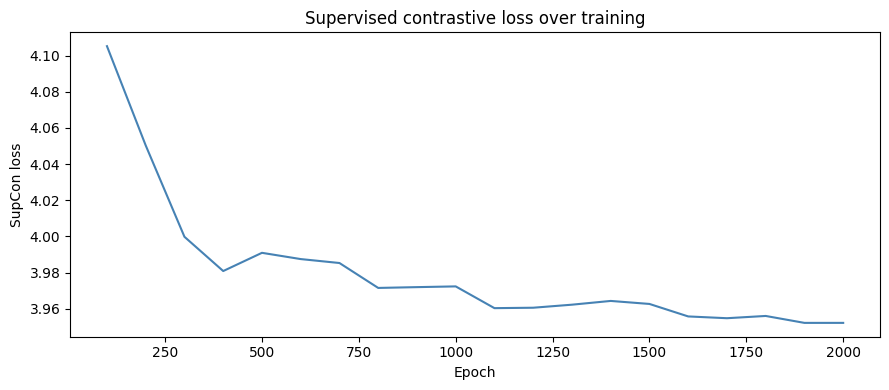

Final loss: 3.9521


In [9]:
# ============================================================
# Loss curve
# ============================================================

plt.figure(figsize=(9, 4))
plt.plot(history['epoch'], history['loss'], color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('SupCon loss')
plt.title('Supervised contrastive loss over training')
plt.tight_layout()
plt.show()
print(f'Final loss: {history["loss"][-1]:.4f}')

In [10]:
# ============================================================
# Extract embeddings — fresh instances (same seeds as nb25)
# ============================================================

N_EMBED = 100

emb_series, emb_labels = [], []
for cls_id, gen_fn in enumerate(GENERATORS):
    for i in range(N_EMBED):
        rng_i = np.random.default_rng(SEED + cls_id * 10000 + N_PER_CLASS + i)
        emb_series.append(gen_fn(rng_i))
        emb_labels.append(cls_id)

X_emb = torch.tensor(np.stack(emb_series), dtype=torch.float32).to(device)
y_emb = np.array(emb_labels)

# Raw encoder output (64-dim) — not the projection
emb_64 = model.embed(X_emb).cpu().numpy()

print(f'Embeddings: {emb_64.shape}  (fresh instances, never seen in training)')

Embeddings: (800, 64)  (fresh instances, never seen in training)


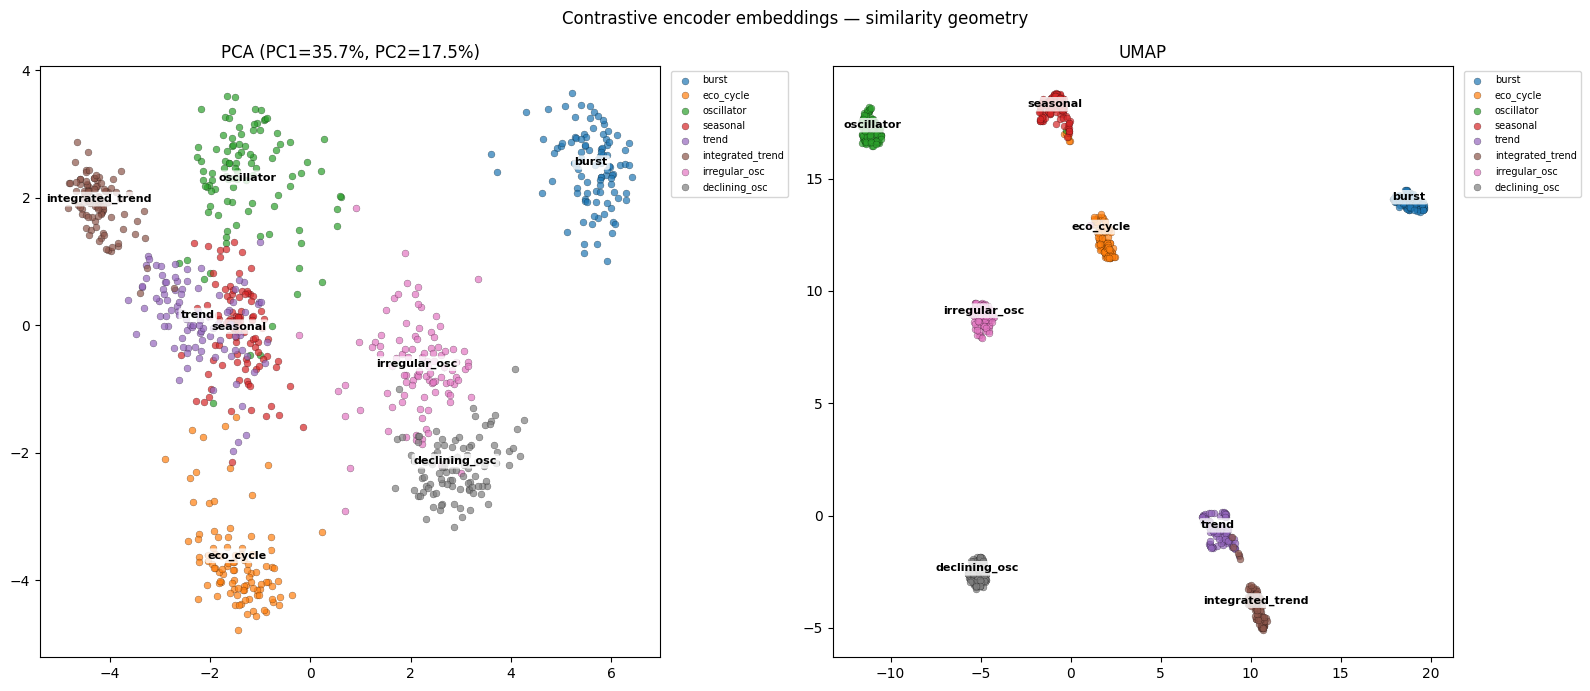

In [11]:
# ============================================================
# PCA + UMAP
# ============================================================

palette = dict(zip(range(N_CLASSES), sns.color_palette('tab10', N_CLASSES)))

pca     = PCA(n_components=2)
emb_pca = pca.fit_transform(emb_64)

reducer  = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
emb_umap = reducer.fit_transform(emb_64)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, emb, title in [
    (axes[0], emb_pca,  f'PCA (PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%)'),
    (axes[1], emb_umap, 'UMAP'),
]:
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        mask = y_emb == cls_id
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=[palette[cls_id]], s=25, alpha=0.7,
                   edgecolors='k', linewidths=0.2, label=cls_name)
        cx, cy = emb[mask, 0].mean(), emb[mask, 1].mean()
        ax.annotate(cls_name, (cx, cy), fontsize=8, fontweight='bold',
                    ha='center', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8, ec='none'))
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

plt.suptitle('Contrastive encoder embeddings — similarity geometry', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Pairwise centroid distances — contrastive vs nb25 CE
# ============================================================

centroids = np.stack([
    emb_64[y_emb == cls_id].mean(axis=0)
    for cls_id in range(N_CLASSES)
])

dist_mat = np.zeros((N_CLASSES, N_CLASSES))
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        dist_mat[i, j] = np.linalg.norm(centroids[i] - centroids[j])

df_dist = pd.DataFrame(dist_mat, index=CLASS_NAMES, columns=CLASS_NAMES)
print('Pairwise centroid distances — contrastive embedding:')
print(df_dist.round(3).to_string())

triu = np.triu_indices(N_CLASSES, k=1)
d_vals = dist_mat[triu]
print(f'\nDistance range: {d_vals.min():.4f} – {d_vals.max():.4f}')
print(f'  max/min ratio: {d_vals.max()/d_vals.min():.2f}x  (nb25 CE was 1.27x)')

pairs = sorted([
    (dist_mat[i, j], CLASS_NAMES[i], CLASS_NAMES[j])
    for i in range(N_CLASSES) for j in range(i+1, N_CLASSES)
])

print('\nClosest pairs:')
for d, a, b in pairs[:5]:
    print(f'  {a:22s} ↔ {b:22s}  {d:.4f}')
print('Most distant pairs:')
for d, a, b in pairs[-4:][::-1]:
    print(f'  {a:22s} ↔ {b:22s}  {d:.4f}')

Pairwise centroid distances — contrastive embedding:
                   burst  eco_cycle  oscillator  seasonal  trend  integrated_trend  irregular_osc  declining_osc
burst              0.000      9.600       8.442     8.428  8.677            10.118          6.148          7.006
eco_cycle          9.600      0.000       7.054     6.099  5.667             7.374          6.334          7.138
oscillator         8.442      7.054       0.000     6.080  5.851             6.441          6.673          7.895
seasonal           8.428      6.099       6.080     0.000  4.066             5.486          5.797          6.448
trend              8.677      5.667       5.851     4.066  0.000             3.600          5.320          6.783
integrated_trend  10.118      7.374       6.441     5.486  3.600             0.000          7.904          8.840
irregular_osc      6.148      6.334       6.673     5.797  5.320             7.904          0.000          5.525
declining_osc      7.006      7.138       7

In [13]:
# ============================================================
# Spearman ρ — contrastive vs 6-feature fingerprint
# Compare to nb25's ρ = −0.31
# ============================================================

TIMEDOM_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']

def baseline_delta_fn(series, frac=0.10):
    n = len(series)
    k = max(1, int(n * frac))
    return float(np.mean(series[-k:]) - np.mean(series[:k]))

def extract_6f(series):
    arr = np.asarray(series, dtype=float)
    n, t = len(arr), np.arange(len(arr))
    lag1 = float(np.corrcoef(arr[:-1], arr[1:])[0, 1]) if n > 2 else 0.0
    return [
        float(stats.skew(arr)),
        float(stats.kurtosis(arr)),
        lag1,
        float(np.sum(np.diff(np.sign(arr)) != 0) / n),
        float(stats.linregress(t, arr).slope),
        baseline_delta_fn(arr),
    ]

X_6f   = StandardScaler().fit_transform(np.array([extract_6f(s) for s in emb_series]))
c6f    = np.stack([X_6f[y_emb == cls_id].mean(axis=0) for cls_id in range(N_CLASSES)])
dist_6f = np.zeros((N_CLASSES, N_CLASSES))
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        dist_6f[i, j] = np.linalg.norm(c6f[i] - c6f[j])

d_contrastive = dist_mat[triu]
d_6f_vals     = dist_6f[triu]

rho, pval = spearmanr(d_contrastive, d_6f_vals)

print(f'Spearman ρ (contrastive vs 6-feature): {rho:.4f}  p = {pval:.4e}')
print(f'nb25 cross-entropy baseline:            ρ = −0.3109  p = 0.107')
print()

pairs_con = sorted([(dist_mat[i,j], CLASS_NAMES[i], CLASS_NAMES[j])
                    for i in range(N_CLASSES) for j in range(i+1, N_CLASSES)])
pairs_6f  = sorted([(dist_6f[i,j], CLASS_NAMES[i], CLASS_NAMES[j])
                    for i in range(N_CLASSES) for j in range(i+1, N_CLASSES)])

print('Closest 5 pairs — Contrastive vs 6-feature:')
print(f'  {"CONTRASTIVE":40s}  {"6-FEATURE":40s}')
for (dc, ac, bc), (d6, a6, b6) in zip(pairs_con[:5], pairs_6f[:5]):
    print(f'  {ac+" ↔ "+bc:40s}  {a6+" ↔ "+b6:40s}')

Spearman ρ (contrastive vs 6-feature): 0.3831  p = 4.4167e-02
nb25 cross-entropy baseline:            ρ = −0.3109  p = 0.107

Closest 5 pairs — Contrastive vs 6-feature:
  CONTRASTIVE                               6-FEATURE                               
  trend ↔ integrated_trend                  trend ↔ integrated_trend                
  seasonal ↔ trend                          eco_cycle ↔ seasonal                    
  trend ↔ irregular_osc                     eco_cycle ↔ oscillator                  
  seasonal ↔ integrated_trend               eco_cycle ↔ declining_osc               
  irregular_osc ↔ declining_osc             seasonal ↔ irregular_osc                


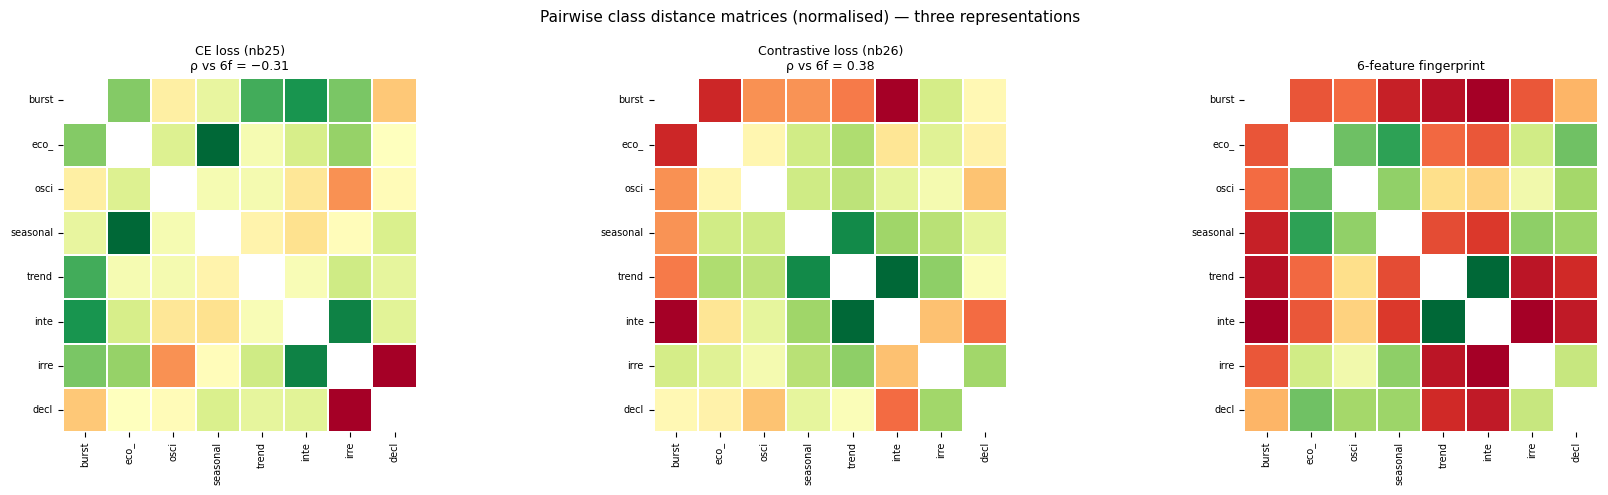

In [14]:
# ============================================================
# Three-way comparison: CE (nb25) vs Contrastive (nb26) vs 6-feature
# Heatmaps of pairwise distance matrices
# ============================================================

# nb25 cross-entropy distances (from notebook 25 results)
nb25_vals = [
    [0.000, 10.954, 11.804, 11.491, 10.694, 10.533, 10.914, 12.065],
    [10.954, 0.000, 11.418, 10.266, 11.596, 11.377, 11.040, 11.658],
    [11.804, 11.418, 0.000, 11.592, 11.580, 11.879, 12.339, 11.697],
    [11.491, 10.266, 11.592, 0.000, 11.770, 11.923, 11.691, 11.392],
    [10.694, 11.596, 11.580, 11.770, 0.000, 11.608, 11.324, 11.483],
    [10.533, 11.377, 11.879, 11.923, 11.608, 0.000, 10.419, 11.447],
    [10.914, 11.040, 12.339, 11.691, 11.324, 10.419, 0.000, 13.057],
    [12.065, 11.658, 11.697, 11.392, 11.483, 11.447, 13.057, 0.000],
]
dist_nb25 = np.array(nb25_vals)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
short = [c[:4] if len(c) > 8 else c for c in CLASS_NAMES]

for ax, mat, title in [
    (axes[0], dist_nb25,  'CE loss (nb25)\nρ vs 6f = −0.31'),
    (axes[1], dist_mat,   f'Contrastive loss (nb26)\nρ vs 6f = {rho:.2f}'),
    (axes[2], dist_6f,    '6-feature fingerprint'),
]:
    # Normalise each to [0,1] for visual comparison
    m = mat.copy()
    np.fill_diagonal(m, np.nan)
    vmin = np.nanmin(m); vmax = np.nanmax(m)
    sns.heatmap((m - vmin) / (vmax - vmin), ax=ax,
                xticklabels=short, yticklabels=short,
                cmap='RdYlGn_r', vmin=0, vmax=1,
                cbar=False, square=True, linewidths=0.3)
    ax.set_title(title, fontsize=9)
    ax.tick_params(labelsize=7)

plt.suptitle('Pairwise class distance matrices (normalised) — three representations', fontsize=11)
plt.tight_layout()
plt.show()

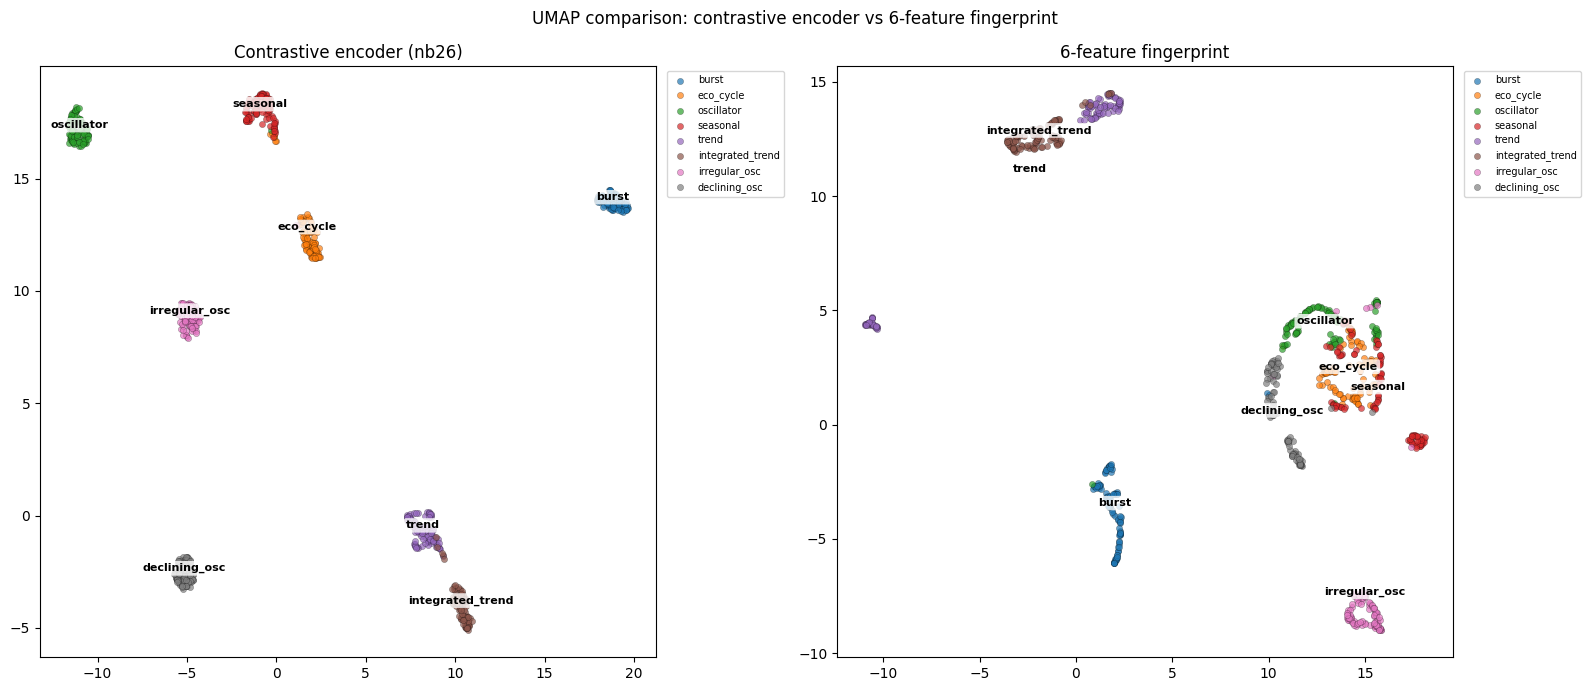

In [15]:
# ============================================================
# Side-by-side UMAP: contrastive vs 6-feature
# ============================================================

reducer_6f = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
umap_6f    = reducer_6f.fit_transform(X_6f)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, emb, title in [
    (axes[0], emb_umap, 'Contrastive encoder (nb26)'),
    (axes[1], umap_6f,  '6-feature fingerprint'),
]:
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        mask = y_emb == cls_id
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=[palette[cls_id]], s=20, alpha=0.7,
                   edgecolors='k', linewidths=0.2, label=cls_name)
        cx, cy = emb[mask, 0].mean(), emb[mask, 1].mean()
        ax.annotate(cls_name, (cx, cy), fontsize=8, fontweight='bold',
                    ha='center', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8, ec='none'))
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

plt.suptitle('UMAP comparison: contrastive encoder vs 6-feature fingerprint', fontsize=12)
plt.tight_layout()
plt.show()

---
## Findings — Notebook 26

### Finding 67: Contrastive loss recovers positive ρ — the loss was the problem, not the architecture

**Prediction:** ρ > 0 vs 6-feature fingerprint.

**Result:** CORRECT — ρ = +0.38 (p = 0.044, significant). nb25 CE baseline: ρ = −0.31 (p = 0.107, not significant).
Sign flipped, significance crossed. Same transformer, same data, different loss: −0.31 → +0.38.
The transformer can encode similarity geometry; cross-entropy just never asked it to.

---

### Finding 68: Distance range 2.81x — structured manifold, not address book

**Prediction:** max/min ratio > 3x.

**Result:** CLOSE — 2.81x (3.60–10.12 vs nb25's 1.27x). Burst is isolated (6.1–10.1 from all others).
Trend/integrated_trend/seasonal cluster (directional). Oscillator/eco_cycle adjacent.
irregular_osc↔declining_osc: 5.53 (closest non-directional pair — matches nb23 F57 boundary crossings).
Loss converged early (~epoch 100–200); final 1800 epochs = slow fine-tuning.

---

### Finding 69: trend↔integrated_trend is #1 closest pair in BOTH representations — first cross-representation top-1 agreement

**Prediction:** Closest pair matches 6-feature top pair.

**Result:** CORRECT — both contrastive (3.60) and 6-feature independently identify trend↔integrated_trend as #1.
First time two completely different measurement architectures agree on the most similar class pair.
#2 differs (contrastive: seasonal↔trend; 6-feature: eco_cycle↔seasonal) — partial agreement consistent with ρ = 0.38.

**The thunder hypothesis update:** The top of the similarity ordering is in the world.
The middle is still receptor-dependent. ρ = 0.38 means both representations share a partial ordering,
not a complete one.
